<a href="https://colab.research.google.com/github/ruforavishnu/Project_Machine_Learning/blob/master/rose_vs_carnation_ml_vs_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🌹 Rose vs 🌺 Carnation — ML vs Deep Learning

Both roses and carnations can be red, so color alone is not enough.

We will:
1. Train a **Machine Learning model** using handcrafted features
2. Train a **Deep Learning CNN** that learns features automatically

We will compare the accuracy and see why Deep Learning shines in subtle image differences.


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from skimage.feature import hog


#Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("l3llff/flowers")

print("Path to dataset files:", path)

100%|██████████| 228M/228M [00:02<00:00, 98.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/l3llff/flowers/versions/4


In [3]:
!ls

sample_data


In [4]:
os.listdir(path)

['flowers']

In [6]:
flowers_path = os.path.join(path, 'flowers')
os.listdir(flowers_path)

['common_daisy',
 'dandelion',
 'california_poppy',
 'iris',
 'daffodil',
 'bellflower',
 'magnolia',
 'astilbe',
 'sunflower',
 'water_lily',
 'coreopsis',
 'carnation',
 'rose',
 'black_eyed_susan',
 'calendula',
 'tulip']

In [7]:
carnation_path = os.path.join(flowers_path, 'carnation')
os.listdir(carnation_path)


['16697522572_5e7f9f3965_c.jpg',
 '15826308350_747c81548e_c.jpg',
 '51286886100_9281986968_c.jpg',
 '5917905521_a6c2ae1229_c.jpg',
 '370672761_4bc05c20e6_c.jpg',
 '1557150963_c1c65ef75c_c.jpg',
 '98128512_cdf48d1d5b_c.jpg',
 '50722252727_5f440e9199_c.jpg',
 '2997615342_84bc2e80af_c.jpg',
 '1129737078_a0f329be57_c.jpg',
 '16928175139_4308481b13_c.jpg',
 '7026739521_2c70a0943f_c.jpg',
 '9070406323_17d452d280_c.jpg',
 '77899870_4ef94556cf_c.jpg',
 '27082632904_1b5a311b67_c.jpg',
 '119735835_e589ddc6d8_c.jpg',
 '35649497483_6292695fa7_c.jpg',
 '409963605_2faef55ae1_c.jpg',
 '517758750_bd385a872a_c.jpg',
 '3989363140_1c526079cc_c.jpg',
 '754434802_24cb0e541d_c.jpg',
 '50254242801_f04ab48c45_c.jpg',
 '49388590637_d7cbf13eec_c.jpg',
 '50726972491_953d3a0077_c.jpg',
 '5067927640_d5ed21ec4d_c.jpg',
 '48037556561_2b1a444fbb_c.jpg',
 '2859803339_ebf3d2effa_c.jpg',
 '12094925633_47e521f72e_c.jpg',
 '14447758017_fe7b1e2d94_c.jpg',
 '51194602434_00643ba7d7_c.jpg',
 '2351615453_7e2272a24f_c.jpg',
 '3

In [8]:
rose_path = os.path.join(flowers_path, 'rose')
os.listdir(rose_path)


['27267493383_5de49a0169_c.jpg',
 '3748717164_738f9469a4_c.jpg',
 '5811196461_e44e113b2a_c.jpg',
 '402579111_3120889eaf_c.jpg',
 '8172245822_c611e5112e_c.jpg',
 '18266970920_0b2784078d_c.jpg',
 '24245728128_1a3f278044_c.jpg',
 '5407233359_634a619159_c.jpg',
 '14284164022_0cf424f1c1_c.jpg',
 '8740797734_1ac752f38d_c.jpg',
 '2572384330_728e14d562_c.jpg',
 '27885929180_98428fe3d5_c.jpg',
 '34119030794_ed5c826677_c.jpg',
 '7387440454_60d7450a64_c.jpg',
 '8079321405_1af34cc55a_c.jpg',
 '21113296146_ca0fbc6baf_c.jpg',
 '1692696743_37dc2eb1ff_c.jpg',
 '3944870816_1f1a1c301c_c.jpg',
 '14240988383_1d3aafab7e_c.jpg',
 '3622856054_4d50ddd306_c.jpg',
 '553803010_2473b60082_c.jpg',
 '12229427556_2c3ccd2aa9_c.jpg',
 '1216789_7e50c0f967_c.jpg',
 '3747929625_1d4d51d288_c.jpg',
 '8984352281_3f6e8394ac_c.jpg',
 '35526147234_6270428c4e_c.jpg',
 '5410469212_6945c99932_c.jpg',
 '30451315300_62f654558f_c.jpg',
 '6136511707_2ec8d847e3_c.jpg',
 '43867827595_d60ee1e8d8_c.jpg',
 '4861285138_01188c5883_c.jpg',
 

In [9]:
import os
import cv2
import random
import matplotlib.pyplot as plt


In [10]:
def show_random_images(folder_path, label, num_images=10):
    # List all image files
    all_images = os.listdir(folder_path)

    # Randomly pick images
    sample_images = random.sample(all_images, min(num_images, len(all_images)))

    plt.figure(figsize=(15,5))

    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(label)
    plt.show()


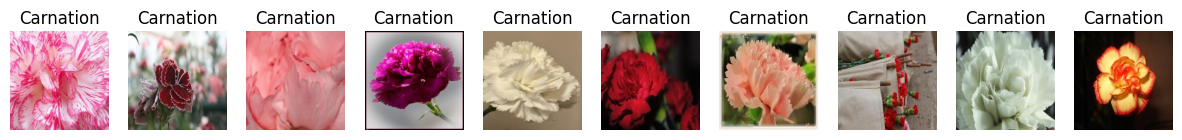

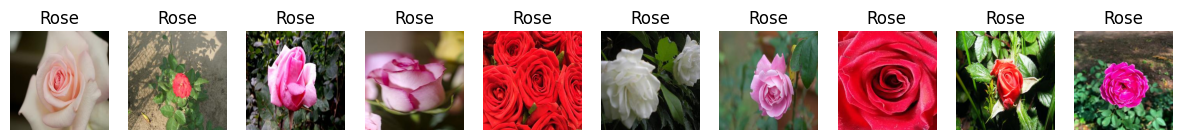

In [11]:
# Show 10 random carnation images
show_random_images(carnation_path, "Carnation", num_images=10)

# Show 10 random rose images
show_random_images(rose_path, "Rose", num_images=10)


In [12]:
IMG_SIZE = 128  # standard size for both ML & DL

# Resize & normalize images
def preprocess_images(folder_path, label):
    images = []
    labels = []
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(label)
    return images, labels

# Load & preprocess
rose_images, rose_labels = preprocess_images(rose_path, 0)
carnation_images, carnation_labels = preprocess_images(carnation_path, 1)

# Combine both classes
X = np.array(rose_images + carnation_images)
y = np.array(rose_labels + carnation_labels)

print("Total images:", len(X))


Total images: 1922


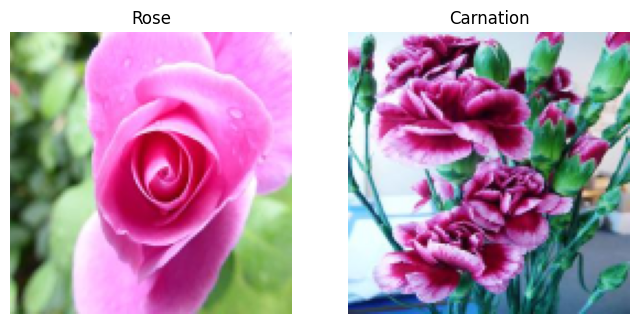

In [13]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(X[0], cv2.COLOR_BGR2RGB))
plt.title("Rose")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(X[-1], cv2.COLOR_BGR2RGB))
plt.title("Carnation")
plt.axis("off")

plt.show()


In [14]:
from skimage.feature import hog

# Convert to grayscale
X_gray = np.array([cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in X])

# Extract HOG features
hog_features = []
for img in X_gray:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )
    hog_features.append(features)

hog_features = np.array(hog_features)
print("HOG features shape:", hog_features.shape)


HOG features shape: (1922, 1764)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    hog_features, y, test_size=0.2, random_state=42
)


In [16]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Initialize & train SVM
ml_model = SVC(kernel='rbf')
ml_model.fit(X_train, y_train)

# Predictions
ml_preds = ml_model.predict(X_test)

# Accuracy
ml_accuracy = accuracy_score(y_test, ml_preds)
print("Machine Learning Accuracy: {:.2f}%".format(ml_accuracy*100))

# Optional: Confusion matrix
cm = confusion_matrix(y_test, ml_preds)
print("Confusion Matrix:\n", cm)


Machine Learning Accuracy: 74.29%
Confusion Matrix:
 [[137  58]
 [ 41 149]]


In [17]:
# Normalize pixel values to [0,1]
X_dl = X / 255.0

# Split for DL
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl, y, test_size=0.2, random_state=42
)


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models

dl_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE,IMG_SIZE,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

dl_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Split manually
from sklearn.model_selection import train_test_split

X_train_aug, X_val_aug, y_train_aug, y_val_aug = train_test_split(
    X_train_dl, y_train_dl, test_size=0.2, random_state=42
)

# Use datagen.flow on training only
train_generator = datagen.flow(X_train_aug, y_train_aug, batch_size=32)

history = dl_model.fit(
    train_generator,
    epochs=30,
    validation_data=(X_val_aug, y_val_aug)
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8056 - loss: 0.6186 - val_accuracy: 0.8961 - val_loss: 0.3063
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.7519 - loss: 0.4839 - val_accuracy: 0.8929 - val_loss: 0.2516
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.7734 - loss: 0.4461 - val_accuracy: 0.9286 - val_loss: 0.2301
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8113 - loss: 0.4200 - val_accuracy: 0.8961 - val_loss: 0.2441
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8309 - loss: 0.3724 - val_accuracy: 0.9253 - val_loss: 0.2124
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8378 - loss: 0.3800 - val_accuracy: 0.8636 - val_loss: 0.3138
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8483 - loss: 0.3569 - val_accuracy: 0.9156 - val_loss: 0.2071
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8589 - loss: 0.3541 - val_accuracy: 0.9318 - val_loss:

In [25]:
dl_loss, dl_accuracy = dl_model.evaluate(X_test_dl, y_test_dl)
print("Deep Learning Accuracy: {:.2f}%".format(dl_accuracy*100))

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 525ms/step - accuracy: 0.8663 - loss: 0.3717
Deep Learning Accuracy: 85.71%


### Now lets compare our results

In [28]:

# Accuracy
ml_accuracy = accuracy_score(y_test, ml_preds)
print("Machine Learning Accuracy: {:.2f}%".format(ml_accuracy*100))


Machine Learning Accuracy: 74.29%


In [27]:
dl_loss, dl_accuracy = dl_model.evaluate(X_test_dl, y_test_dl)
print("Deep Learning Accuracy: {:.2f}%".format(dl_accuracy*100))

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step - accuracy: 0.8663 - loss: 0.3717
Deep Learning Accuracy: 85.71%


## Results

Machine Learning AI model obtained an accuracy of 74.29%
Deep Learning AI model obtained an accuracy of 85.71%

that is a huge 11% increase in accuracy.






**Deep Learning surely wins over Machine Learning.**